# Imports

In [1]:
import pandas as pd
import numpy as np

# Get and Format Data

In [2]:
def prepare_data(data, year):
    data = data.rename(columns=lambda x: x[2:] if x[1]=='_' else x)
    data['year'] = year
    data = data.sample(frac=1)
    return data

In [3]:
amazon_train_sets = [prepare_data(pd.read_csv(f"datasets/amazon_train_{year}.csv"), year) for year in range(2021, 2024)]
amazon_train = pd.concat(amazon_train_sets, axis=0)

taiga_train_sets = [prepare_data(pd.read_csv(f"datasets/taiga_train_{year}.csv"), year) for year in range(2021, 2024)]
taiga_train = pd.concat(taiga_train_sets, axis=0)

borneo_train_sets = [prepare_data(pd.read_csv(f"datasets/borneo_train_{year}.csv"), year) for year in range(2021, 2024)]
borneo_train = pd.concat(borneo_train_sets, axis=0)

train_set = pd.concat([amazon_train, taiga_train, borneo_train], axis=0)
train_set = train_set.sample(frac=1)
train_set = train_set.sort_values(by='year').reset_index()
print(train_set.head())
print(train_set.groupby('year')['class'].count())

   index system:index  NBR_delta_lag4  NBR_lag4  NDMI_delta_lag4  NDMI_lag4  \
0    236     1_1236_0        0.044299  0.286446         0.042124   0.148892   
1    643     1_1654_0        0.052274  0.419749         0.037044   0.261343   
2   1576      2_617_0       -0.028779  0.346690        -0.038350   0.233438   
3      3     1_1003_0        0.153798  0.345304         0.191541   0.212002   
4   1678      2_678_0        0.046369  0.238151         0.043612   0.130182   

   NDVI_delta_lag4  NDVI_lag4  SR_B4_delta_lag4  SR_B4_lag4  ...  SR_B5_lag1  \
0         0.020166   0.356235            -485.5      8372.0  ...     18827.0   
1         0.064127   0.488493             -27.5      8184.5  ...     21314.5   
2        -0.019630   0.382822             -50.0      8235.0  ...     17646.5   
3         0.100775   0.385871           -1693.5      8350.0  ...     18645.0   
4         0.033525   0.267048             348.0      9233.0  ...     14046.0   

   SR_B6_delta_lag1  SR_B6_lag1  SR_B7_delta

# Feature Selection

In [4]:
all_features = train_set.columns.drop(['year', 'index', 'system:index', 'class', 'latitude', 'longitude', '.geo', 'year'])
print(all_features)

Index(['NBR_delta_lag4', 'NBR_lag4', 'NDMI_delta_lag4', 'NDMI_lag4',
       'NDVI_delta_lag4', 'NDVI_lag4', 'SR_B4_delta_lag4', 'SR_B4_lag4',
       'SR_B5_delta_lag4', 'SR_B5_lag4', 'SR_B6_delta_lag4', 'SR_B6_lag4',
       'SR_B7_delta_lag4', 'SR_B7_lag4', 'NBR_delta_lag3', 'NBR_lag3',
       'NDMI_delta_lag3', 'NDMI_lag3', 'NDVI_delta_lag3', 'NDVI_lag3',
       'SR_B4_delta_lag3', 'SR_B4_lag3', 'SR_B5_delta_lag3', 'SR_B5_lag3',
       'SR_B6_delta_lag3', 'SR_B6_lag3', 'SR_B7_delta_lag3', 'SR_B7_lag3',
       'NBR_delta_lag2', 'NBR_lag2', 'NDMI_delta_lag2', 'NDMI_lag2',
       'NDVI_delta_lag2', 'NDVI_lag2', 'SR_B4_delta_lag2', 'SR_B4_lag2',
       'SR_B5_delta_lag2', 'SR_B5_lag2', 'SR_B6_delta_lag2', 'SR_B6_lag2',
       'SR_B7_delta_lag2', 'SR_B7_lag2', 'NBR_delta_lag1', 'NBR_lag1',
       'NDMI_delta_lag1', 'NDMI_lag1', 'NDVI_delta_lag1', 'NDVI_lag1',
       'SR_B4_delta_lag1', 'SR_B4_lag1', 'SR_B5_delta_lag1', 'SR_B5_lag1',
       'SR_B6_delta_lag1', 'SR_B6_lag1', 'SR_B7_delta_lag

In [5]:
X_train = train_set[all_features]
y_train = train_set['class']

class               1.000000
NBR_delta_lag3      0.544072
SR_B7_delta_lag3    0.543627
SR_B7_delta_lag4    0.542301
SR_B7_delta_lag2    0.535465
NBR_delta_lag4      0.533444
NBR_delta_lag2      0.533070
SR_B7_delta_lag1    0.509305
NDMI_delta_lag3     0.498901
NDMI_delta_lag4     0.493961
NBR_delta_lag1      0.493442
NDMI_delta_lag2     0.486412
NDVI_delta_lag3     0.446424
NDMI_delta_lag1     0.443067
SR_B6_delta_lag4    0.441876
SR_B6_delta_lag3    0.439632
NDVI_delta_lag2     0.438087
NDVI_delta_lag4     0.435486
SR_B6_delta_lag2    0.430869
SR_B6_delta_lag1    0.413092
NDVI_delta_lag1     0.408822
SR_B5_delta_lag3    0.222721
SR_B5_delta_lag2    0.209143
SR_B5_delta_lag4    0.205878
SR_B4_delta_lag3    0.202897
SR_B4_delta_lag2    0.199912
SR_B4_delta_lag1    0.197277
SR_B4_delta_lag4    0.189832
NDMI_lag1           0.172276
SR_B5_delta_lag1    0.171142
SR_B7_lag1          0.156176
SR_B6_lag1          0.151665
SR_B6_lag3          0.130178
SR_B6_lag2          0.129420
SR_B6_lag4    

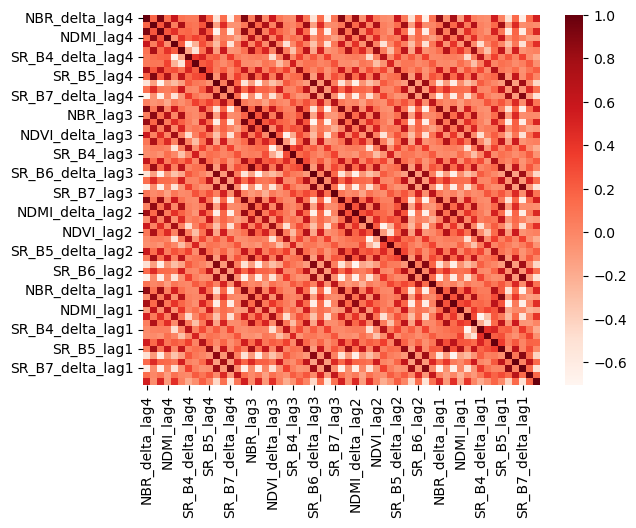

In [6]:
import seaborn as sns
sns.heatmap(pd.concat([X_train, y_train], axis=1).corr(), cmap='Reds')
print(abs(pd.concat([X_train, y_train], axis=1).corr()['class']).sort_values(ascending=False))

In [7]:
def custom_year_ts_split(df, year_col):
    # Get unique years and sort them
    years = sorted(df[year_col].unique())
    
    # We need at least 2 years to do one split (Train Y1 -> Val Y2)
    for i in range(1, len(years)):
        # Training set: All years up to the current split
        train_indices = df[df[year_col].isin(years[:i])].index.values
        
        # Validation set: The very next year
        val_indices = df[df[year_col] == years[i]].index.values
        yield train_indices, val_indices

# Logistic Regression

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_validate

cv_iterator = custom_year_ts_split(train_set, 'year')
logistic_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', LogisticRegressionCV(
        cv=5, 
        l1_ratios=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], 
        max_iter=5000,
        solver='saga',
        random_state=1,
        use_legacy_attributes=False))])
logistic_results = cross_validate(
    logistic_pipe, 
    X_train, 
    y_train, 
    cv=cv_iterator, 
    return_estimator=True,
    scoring=['f1', 'precision', 'recall'], 
    return_train_score=True  # Crucial for detecting overfitting
)

In [23]:
print(f"Mean Test f1: {logistic_results['test_f1'].mean():.4f}")
print(f"Mean Test Precision: {logistic_results['test_precision'].mean():.4f}")
print(f"Mean Test Recall: {logistic_results['test_recall'].mean():.4f}")

print(f"Mean Train f1: {logistic_results['train_f1'].mean():.4f}")
print(f"Mean Train Precision: {logistic_results['train_precision'].mean():.4f}")
print(f"Mean Train Recall: {logistic_results['train_recall'].mean():.4f}")

Mean Test f1: 0.8329
Mean Test Precision: 0.9074
Mean Test Recall: 0.7696
Mean Train f1: 0.8490
Mean Train Precision: 0.8904
Mean Train Recall: 0.8114


# XGBoost

In [24]:
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from xgboost import XGBClassifier

In [25]:
xgboost_param_grid = {
    'max_depth': Integer(3, 5),
    'min_child_weight': Integer (1, 200),
    'subsample': Real(0.7, 1),
    'colsample_bylevel': Real(0.5, 1),
    'colsample_bynode': Real(0.5, 1),
    'reg_lambda': Real(0, 10),
    'reg_alpha': Real(0, 10)
}

In [26]:
xgb_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', BayesSearchCV(
        estimator=XGBClassifier(objective='binary:logistic', random_state=1, learning_rate=0.3, tree_method='hist'),
        cv=5, 
        refit='f1',
        search_spaces=xgboost_param_grid,
        random_state=1,
        scoring='f1'
    ))])

cv_iterator = custom_year_ts_split(train_set, 'year')

xgb_results = cross_validate(
    xgb_pipe,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [27]:
# Now you can iterate through the estimators (one for each outer fold)
for i, estimator in enumerate(xgb_results['estimator']):
    print(f"Outer Fold {i+1} Inner Mean Score: {estimator.best_score_:.4f}")
    # To see the gap we discussed:
    inner_results = estimator.cv_results_
    print(f"Outer Fold {i+1} Inner Std Dev: {inner_results['std_test_score'][estimator.best_index_]:.4f}")

AttributeError: 'Pipeline' object has no attribute 'best_score_'

In [28]:
print(f"Mean Test f1: {xgb_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {xgb_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {xgb_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {xgb_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {xgb_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {xgb_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-xgb_results['test_f1'].mean()/xgb_results['train_f1'].mean()}")

Mean Test f1: 0.86549446
Mean Test Precision: 0.91299381
Mean Test Recall: 0.82269454
Mean Train f1: 0.97282284
Mean Train Precision: 0.98463077
Mean Train Recall: 0.96135487
Overfitting Ratio: 0.11032675014109883


# SVC

In [29]:
from sklearn.svm import SVC

In [30]:
svc_param_grid = {
    'C': Real(0, 10),
    'kernel': Categorical(['linear', 'poly', 'rbf'])
}

In [ ]:
svc_pipe = Pipeline([
    ('transformer', PowerTransformer('yeo-johnson')),
    ('model', BayesSearchCV(
        estimator=SVC(random_state=1),
        cv=5, 
        refit='f1',
        search_spaces=svc_param_grid,
        random_state=1,
        scoring='f1'
    ))])

cv_iterator = custom_year_ts_split(train_set, 'year')

svc_results = cross_validate(
    svc_pipe,
    X_train, 
    y_train, 
    cv=cv_iterator, 
    scoring=['f1', 'precision', 'recall'], 
    return_estimator=True,
    return_train_score=True  # Crucial for detecting overfitting
)

In [ ]:
# Now you can iterate through the estimators (one for each outer fold)
for i, estimator in enumerate(svc_results['estimator']):
    print(f"Outer Fold {i+1} Inner Mean Score: {estimator.best_score_:.4f}")
    # To see the gap we discussed:
    inner_results = estimator.cv_results_
    print(f"Outer Fold {i+1} Inner Std Dev: {inner_results['std_test_score'][estimator.best_index_]:.4f}")

In [ ]:
print(f"Mean Test f1: {svc_results['test_f1'].mean():.8f}")
print(f"Mean Test Precision: {svc_results['test_precision'].mean():.8f}")
print(f"Mean Test Recall: {svc_results['test_recall'].mean():.8f}")

print(f"Mean Train f1: {svc_results['train_f1'].mean():.8f}")
print(f"Mean Train Precision: {svc_results['train_precision'].mean():.8f}")
print(f"Mean Train Recall: {svc_results['train_recall'].mean():.8f}")

print(f"Overfitting Ratio: {1-svc_results['test_f1'].mean()/svc_results['train_f1'].mean()}")